In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime

# Create sample subscription lending facility data
funds_data = {
    'Fund_Name': ['Blackstone BDC I', 'Oaktree Direct Lending III', 'Apollo Credit Partners VI',
                  'Ares Direct Lending VIII', 'KKR Credit Opportunities', 'TPG Specialty Lending',
                  'Carlyle Asia Partners III', 'Antares Leveraged Finance', 'Blue Owl Credit',
                  'Golub Capital BDC 7', 'Benefit Street Partners Credit', 'Mizuho Direct Lending',
                  'Truemark Tech Finance', 'Lexington Partners Tech Fund', 'Coller International VIII'],
    'Strategy': ['Buyout', 'Direct Lending', 'Credit', 'Direct Lending', 'Growth Equity',
                 'Specialty Lending', 'Asia Growth', 'Direct Lending', 'Credit',
                 'Diversified Credit', 'Credit', 'Direct Lending', 'Tech Growth', 'Tech', 'Growth'],
    'LP_Commitments_MM': [2500, 3200, 2800, 3500, 1800, 2200, 2600, 2100, 3000, 2400, 1900, 2300, 1700, 2500, 2900],
    'LP_Unfunded_MM': [800, 950, 700, 1200, 400, 600, 850, 500, 900, 650, 550, 700, 450, 800, 700],
    'Subscription_Line_Size_MM': [1500, 1800, 1600, 2000, 1000, 1300, 1500, 1200, 1700, 1400, 1100, 1350, 1000, 1500, 1600],
    'Current_Utilization_MM': [1200, 1450, 1280, 1600, 750, 950, 1100, 850, 1300, 1050, 780, 1000, 650, 1100, 1150],
    'Interest_Rate_pct': [3.5, 3.2, 3.8, 3.0, 4.2, 3.6, 3.9, 3.4, 3.1, 3.7, 3.5, 3.3, 4.5, 3.8, 3.6],
    'Covenant_Leverage_Ratio': [0.45, 0.52, 0.48, 0.50, 0.38, 0.42, 0.46, 0.41, 0.49, 0.44, 0.39, 0.47, 0.35, 0.51, 0.43],
    'Redemption_Rate_YoY_pct': [5, 8, 6, 7, 4, 6, 7, 5, 8, 6, 5, 7, 3, 6, 6]
}

df = pd.DataFrame(funds_data)
print("Fund Finance Subscription Lending Data Loaded")
print(df.head(10))

Fund Finance Subscription Lending Data Loaded
                    Fund_Name            Strategy  LP_Commitments_MM  \
0            Blackstone BDC I              Buyout               2500   
1  Oaktree Direct Lending III      Direct Lending               3200   
2   Apollo Credit Partners VI              Credit               2800   
3    Ares Direct Lending VIII      Direct Lending               3500   
4    KKR Credit Opportunities       Growth Equity               1800   
5       TPG Specialty Lending   Specialty Lending               2200   
6   Carlyle Asia Partners III         Asia Growth               2600   
7   Antares Leveraged Finance      Direct Lending               2100   
8             Blue Owl Credit              Credit               3000   
9         Golub Capital BDC 7  Diversified Credit               2400   

   LP_Unfunded_MM  Subscription_Line_Size_MM  Current_Utilization_MM  \
0             800                       1500                    1200   
1             950

In [2]:
# STEP 2: Calculate Borrowing Base and Key Risk Metrics

# 1. Available Borrowing Base
# = Unfunded LP Commitments - Reserve requirement (typically 10-15% of commitments)
reserve_pct = 0.10  # 10% reserve requirement
df['Total_Borrowing_Capacity_MM'] = df['LP_Unfunded_MM'] - (df['LP_Commitments_MM'] * reserve_pct)

# 2. Current Leverage Ratio
# = Current Subscription Borrowing / Total LP Commitments (lower is safer)
df['Current_Leverage_Ratio'] = df['Current_Utilization_MM'] / df['LP_Commitments_MM']

# 3. Available Headroom on Subscription Line
# = How much more they can borrow on the facility
df['Available_Line_Capacity_MM'] = df['Subscription_Line_Size_MM'] - df['Current_Utilization_MM']

# 4. Borrowing Base Utilization
# = Current Borrowing / Available Borrowing Capacity (% used)
df['Borrowing_Base_Utilization_pct'] = (df['Current_Utilization_MM'] / df['Total_Borrowing_Capacity_MM']) * 100

# 5. Covenant Leverage Threshold (assume max allowed = 0.60)
max_covenant_leverage = 0.60
df['Covenant_Headroom_Ratio'] = (max_covenant_leverage - df['Current_Leverage_Ratio']) / max_covenant_leverage

# 6. Interest Expense (annual debt service)
df['Annual_Interest_Expense_MM'] = df['Current_Utilization_MM'] * (df['Interest_Rate_pct'] / 100)

# Create a summary table
summary_table = df[['Fund_Name', 'Current_Leverage_Ratio', 'Covenant_Leverage_Ratio',
                     'Available_Line_Capacity_MM', 'Covenant_Headroom_Ratio',
                     'Borrowing_Base_Utilization_pct']].copy()

print("=" * 100)
print("FUND FINANCE RISK METRICS - COVENANT ANALYSIS")
print("=" * 100)
print(summary_table.to_string(index=False))
print("=" * 100)

FUND FINANCE RISK METRICS - COVENANT ANALYSIS
                     Fund_Name  Current_Leverage_Ratio  Covenant_Leverage_Ratio  Available_Line_Capacity_MM  Covenant_Headroom_Ratio  Borrowing_Base_Utilization_pct
              Blackstone BDC I                0.480000                     0.45                         300                 0.200000                      218.181818
    Oaktree Direct Lending III                0.453125                     0.52                         350                 0.244792                      230.158730
     Apollo Credit Partners VI                0.457143                     0.48                         320                 0.238095                      304.761905
      Ares Direct Lending VIII                0.457143                     0.50                         400                 0.238095                      188.235294
      KKR Credit Opportunities                0.416667                     0.38                         250                 0.305

In [3]:
# STEP 3: Stress Test Scenarios
# Model how funds perform if LPs redeem or commitments shrink

# Create stress test scenarios
df_base = df.copy()

# ===== DOWNSIDE SCENARIO =====
# LP commitments drop 15%, redemptions increase, need more cash
df_downside = df.copy()
df_downside['LP_Commitments_MM'] = df_downside['LP_Commitments_MM'] * 0.85  # -15% commitments
df_downside['LP_Unfunded_MM'] = df_downside['LP_Unfunded_MM'] * 0.80  # -20% unfunded (more redemptions)
df_downside['Current_Utilization_MM'] = df_downside['Current_Utilization_MM'] * 1.05  # +5% need to borrow more

# Recalculate leverage under downside
df_downside['Leverage_Ratio'] = df_downside['Current_Utilization_MM'] / df_downside['LP_Commitments_MM']
df_downside['Covenant_Breach'] = df_downside['Leverage_Ratio'] > 0.60

# ===== SEVERE SCENARIO =====
# LP commitments drop 30%, major redemptions, severe stress
df_severe = df.copy()
df_severe['LP_Commitments_MM'] = df_severe['LP_Commitments_MM'] * 0.70  # -30% commitments
df_severe['LP_Unfunded_MM'] = df_severe['LP_Unfunded_MM'] * 0.50  # -50% unfunded (mass redemptions)
df_severe['Current_Utilization_MM'] = df_severe['Current_Utilization_MM'] * 1.15  # +15% forced to borrow more

# Recalculate leverage under severe
df_severe['Leverage_Ratio'] = df_severe['Current_Utilization_MM'] / df_severe['LP_Commitments_MM']
df_severe['Covenant_Breach'] = df_severe['Leverage_Ratio'] > 0.60

# ===== CREATE COMPARISON TABLE =====
stress_comparison = pd.DataFrame({
    'Fund_Name': df['Fund_Name'],
    'Base_Leverage': df['Current_Leverage_Ratio'].round(3),
    'Downside_Leverage': df_downside['Leverage_Ratio'].round(3),
    'Severe_Leverage': df_severe['Leverage_Ratio'].round(3),
    'Downside_Breach': df_downside['Covenant_Breach'],
    'Severe_Breach': df_severe['Covenant_Breach']
})

print("\n" + "=" * 130)
print("STRESS TEST RESULTS - COVENANT BREACH ANALYSIS")
print("="

_IncompleteInputError: incomplete input (1921611595.py, line 41)

In [4]:
# STEP 3: Stress Test Scenarios
# Model how funds perform if LPs redeem or commitments shrink

# Create stress test scenarios
df_base = df.copy()

# ===== DOWNSIDE SCENARIO =====
# LP commitments drop 15%, redemptions increase, need more cash
df_downside = df.copy()
df_downside['LP_Commitments_MM'] = df_downside['LP_Commitments_MM'] * 0.85  # -15% commitments
df_downside['LP_Unfunded_MM'] = df_downside['LP_Unfunded_MM'] * 0.80  # -20% unfunded (more redemptions)
df_downside['Current_Utilization_MM'] = df_downside['Current_Utilization_MM'] * 1.05  # +5% need to borrow more

# Recalculate leverage under downside
df_downside['Leverage_Ratio'] = df_downside['Current_Utilization_MM'] / df_downside['LP_Commitments_MM']
df_downside['Covenant_Breach'] = df_downside['Leverage_Ratio'] > 0.60

# ===== SEVERE SCENARIO =====
# LP commitments drop 30%, major redemptions, severe stress
df_severe = df.copy()
df_severe['LP_Commitments_MM'] = df_severe['LP_Commitments_MM'] * 0.70  # -30% commitments
df_severe['LP_Unfunded_MM'] = df_severe['LP_Unfunded_MM'] * 0.50  # -50% unfunded (mass redemptions)
df_severe['Current_Utilization_MM'] = df_severe['Current_Utilization_MM'] * 1.15  # +15% forced to borrow more

# Recalculate leverage under severe
df_severe['Leverage_Ratio'] = df_severe['Current_Utilization_MM'] / df_severe['LP_Commitments_MM']
df_severe['Covenant_Breach'] = df_severe['Leverage_Ratio'] > 0.60

# ===== CREATE COMPARISON TABLE =====
stress_comparison = pd.DataFrame({
    'Fund_Name': df['Fund_Name'],
    'Base_Leverage': df['Current_Leverage_Ratio'].round(3),
    'Downside_Leverage': df_downside['Leverage_Ratio'].round(3),
    'Severe_Leverage': df_severe['Leverage_Ratio'].round(3),
    'Downside_Breach': df_downside['Covenant_Breach'],
    'Severe_Breach': df_severe['Covenant_Breach']
})

print("\n" + "=" * 130)
print("STRESS TEST RESULTS - COVENANT BREACH ANALYSIS")
print("=" * 130)
print(stress_comparison.to_string(index=False))
print("=" * 130)

# Count breaches
downside_breaches = df_downside['Covenant_Breach'].sum()
severe_breaches = df_severe['Covenant_Breach'].sum()

print(f"\nDOWNSIDE SCENARIO (LP Commitments -15%, Redemptions +20%):")
print(f"  Funds in Covenant Breach: {downside_breaches} / 15")
print(f"\nSEVERE SCENARIO (LP Commitments -30%, Redemptions +50%):")
print(f"  Funds in Covenant Breach: {severe_breaches} / 15")

# Identify highest risk funds
print("\n" + "=" * 130)
print("HIGHEST RISK FUNDS (Largest Leverage Increase)")
print("=" * 130)
risk_funds = stress_comparison.copy()
risk_funds['Leverage_Increase_to_Severe'] = (risk_funds['Severe_Leverage'] - risk_funds['Base_Leverage']).round(3)
risk_funds_sorted = risk_funds.sort_values('Leverage_Increase_to_Severe', ascending=False).head(5)
print(risk_funds_sorted.to_string(index=False))
print("=" * 130)


STRESS TEST RESULTS - COVENANT BREACH ANALYSIS
                     Fund_Name  Base_Leverage  Downside_Leverage  Severe_Leverage  Downside_Breach  Severe_Breach
              Blackstone BDC I          0.480              0.593            0.789            False           True
    Oaktree Direct Lending III          0.453              0.560            0.744            False           True
     Apollo Credit Partners VI          0.457              0.565            0.751            False           True
      Ares Direct Lending VIII          0.457              0.565            0.751            False           True
      KKR Credit Opportunities          0.417              0.515            0.685            False           True
         TPG Specialty Lending          0.432              0.533            0.709            False           True
     Carlyle Asia Partners III          0.423              0.523            0.695            False           True
     Antares Leveraged Finance          

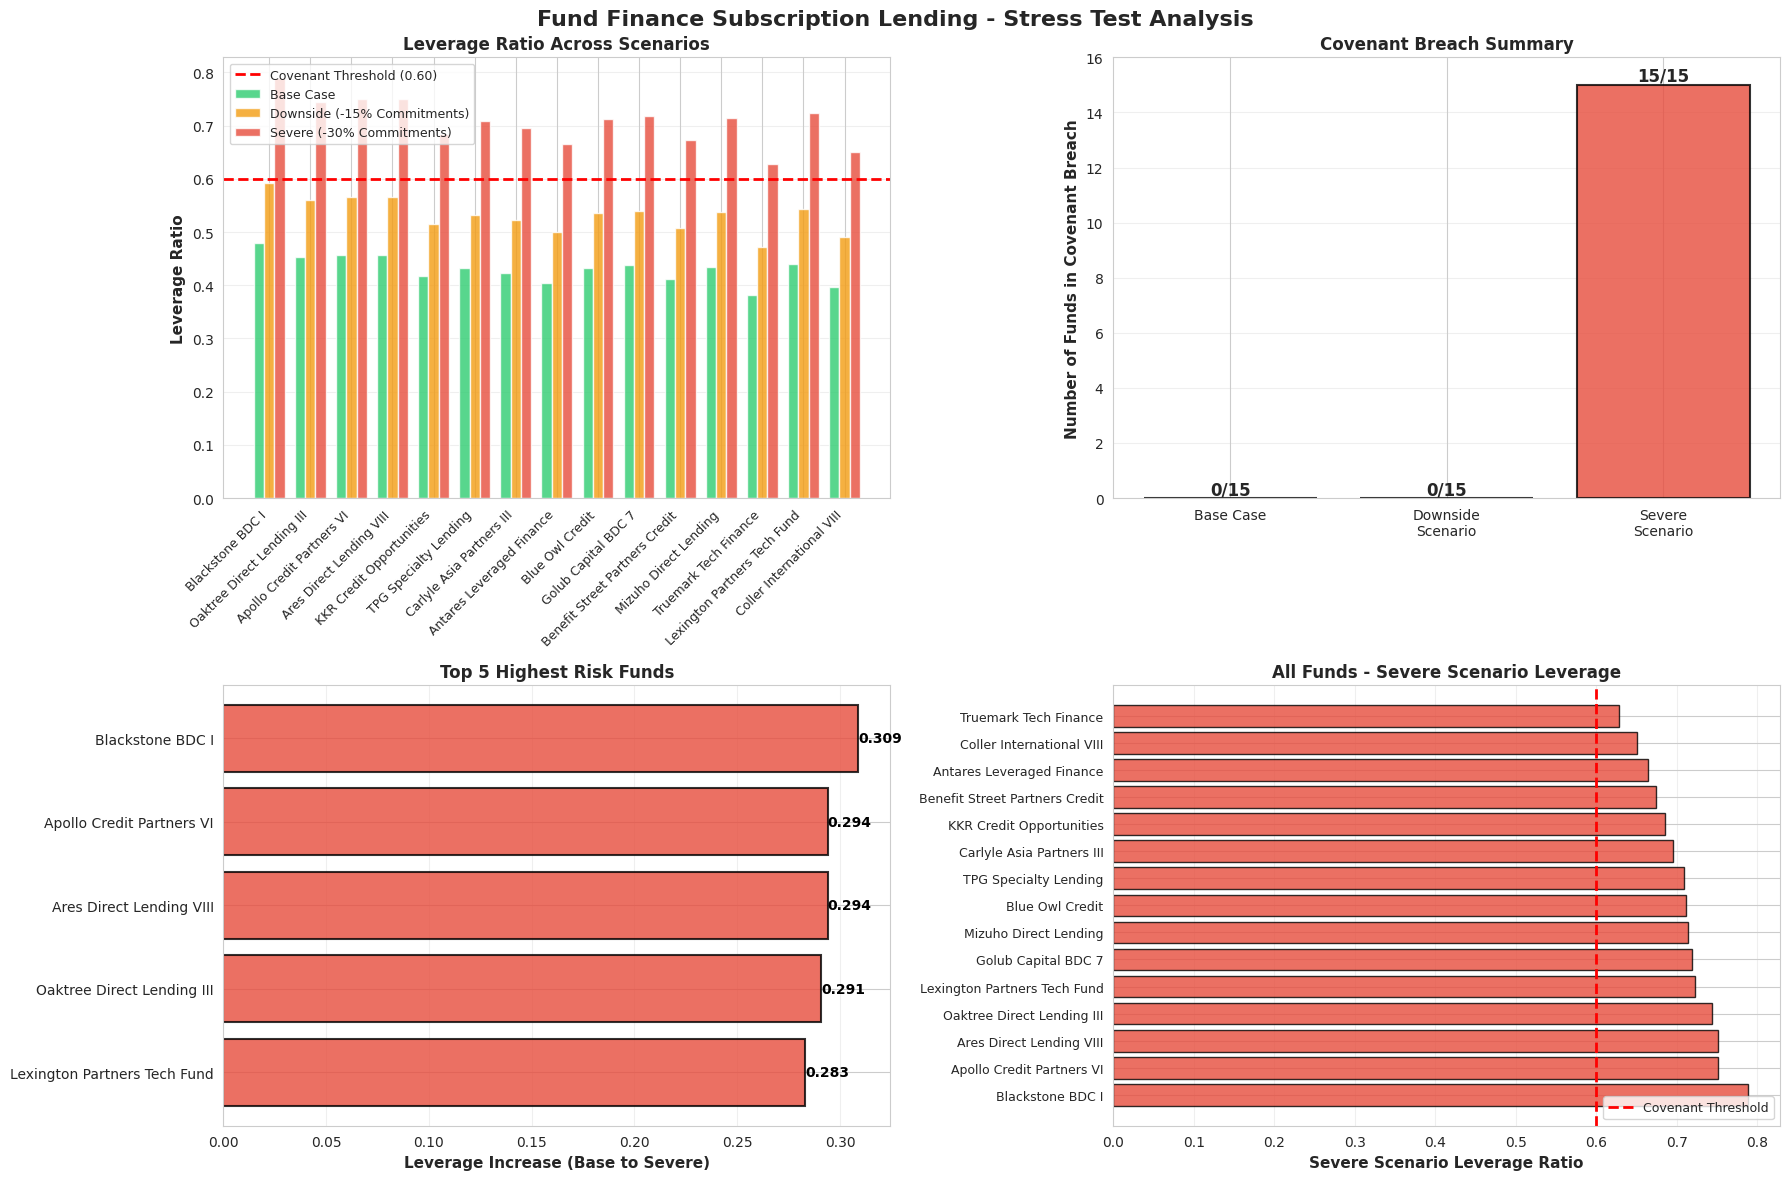


✅ Visualizations Complete!


In [5]:
# STEP 4: Create Professional Visualizations

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional look
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a figure with 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Fund Finance Subscription Lending - Stress Test Analysis', fontsize=16, fontweight='bold')

# ===== CHART 1: Leverage Across Scenarios =====
ax1 = axes[0, 0]
x = range(len(stress_comparison))
width = 0.25

ax1.bar([i - width for i in x], stress_comparison['Base_Leverage'], width, label='Base Case', color='#2ecc71', alpha=0.8)
ax1.bar(x, stress_comparison['Downside_Leverage'], width, label='Downside (-15% Commitments)', color='#f39c12', alpha=0.8)
ax1.bar([i + width for i in x], stress_comparison['Severe_Leverage'], width, label='Severe (-30% Commitments)', color='#e74c3c', alpha=0.8)

# Add covenant threshold line
ax1.axhline(y=0.60, color='red', linestyle='--', linewidth=2, label='Covenant Threshold (0.60)')

ax1.set_ylabel('Leverage Ratio', fontsize=11, fontweight='bold')
ax1.set_title('Leverage Ratio Across Scenarios', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(stress_comparison['Fund_Name'], rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ===== CHART 2: Covenant Breach Count =====
ax2 = axes[0, 1]
scenarios = ['Base Case', 'Downside\nScenario', 'Severe\nScenario']
breach_counts = [0, downside_breaches, severe_breaches]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars = ax2.bar(scenarios, breach_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Funds in Covenant Breach', fontsize=11, fontweight='bold')
ax2.set_title('Covenant Breach Summary', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 16])

# Add value labels on bars
for bar, count in zip(bars, breach_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}/15', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.grid(axis='y', alpha=0.3)

# ===== CHART 3: Risk Ranking (Leverage Increase) =====
ax3 = axes[1, 0]
risk_sorted = risk_funds_sorted.sort_values('Leverage_Increase_to_Severe', ascending=True)

bars3 = ax3.barh(range(len(risk_sorted)), risk_sorted['Leverage_Increase_to_Severe'],
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_yticks(range(len(risk_sorted)))
ax3.set_yticklabels(risk_sorted['Fund_Name'], fontsize=10)
ax3.set_xlabel('Leverage Increase (Base to Severe)', fontsize=11, fontweight='bold')
ax3.set_title('Top 5 Highest Risk Funds', fontsize=12, fontweight='bold')

# Add value labels
for i, (bar, val) in enumerate(zip(bars3, risk_sorted['Leverage_Increase_to_Severe'])):
    ax3.text(val, bar.get_y() + bar.get_height()/2., f'{val:.3f}',
             ha='left', va='center', fontsize=10, fontweight='bold', color='black')

ax3.grid(axis='x', alpha=0.3)

# ===== CHART 4: Severe Scenario Leverage Distribution =====
ax4 = axes[1, 1]
severe_sorted = stress_comparison.sort_values('Severe_Leverage', ascending=False)

colors_severe = ['#e74c3c' if x > 0.60 else '#f39c12' for x in severe_sorted['Severe_Leverage']]
bars4 = ax4.barh(range(len(severe_sorted)), severe_sorted['Severe_Leverage'],
                   color=colors_severe, alpha=0.8, edgecolor='black', linewidth=1)
ax4.axvline(x=0.60, color='red', linestyle='--', linewidth=2, label='Covenant Threshold')

ax4.set_yticks(range(len(severe_sorted)))
ax4.set_yticklabels(severe_sorted['Fund_Name'], fontsize=9)
ax4.set_xlabel('Severe Scenario Leverage Ratio', fontsize=11, fontweight='bold')
ax4.set_title('All Funds - Severe Scenario Leverage', fontsize=12, fontweight='bold')
ax4.legend(loc='lower right', fontsize=9)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualizations Complete!")

In [6]:
# STEP 5: Save to SQL Database (for portfolio monitoring)

# Create SQLite database
conn = sqlite3.connect('fund_finance_analysis.db')

# Save main data to SQL
df.to_sql('funds_base_case', conn, index=False, if_exists='replace')
df_downside.to_sql('funds_downside_scenario', conn, index=False, if_exists='replace')
df_severe.to_sql('funds_severe_scenario', conn, index=False, if_exists='replace')

# Query example: Find all funds in covenant breach under severe scenario
query = """
SELECT Fund_Name, Leverage_Ratio
FROM funds_severe_scenario
WHERE Leverage_Ratio > 0.60
ORDER BY Leverage_Ratio DESC
"""

covenant_breach_funds = pd.read_sql_query(query, conn)
print("Funds in Covenant Breach (Severe Scenario):")
print(covenant_breach_funds)

conn.close()
print("\n✅ Database saved as 'fund_finance_analysis.db'")

Funds in Covenant Breach (Severe Scenario):
                         Fund_Name  Leverage_Ratio
0                 Blackstone BDC I        0.788571
1        Apollo Credit Partners VI        0.751020
2         Ares Direct Lending VIII        0.751020
3       Oaktree Direct Lending III        0.744420
4     Lexington Partners Tech Fund        0.722857
5              Golub Capital BDC 7        0.718750
6            Mizuho Direct Lending        0.714286
7                  Blue Owl Credit        0.711905
8            TPG Specialty Lending        0.709416
9        Carlyle Asia Partners III        0.695055
10        KKR Credit Opportunities        0.684524
11  Benefit Street Partners Credit        0.674436
12       Antares Leveraged Finance        0.664966
13       Coller International VIII        0.651478
14           Truemark Tech Finance        0.628151

✅ Database saved as 'fund_finance_analysis.db'
